
## <div style="text-align: center;"> Grievance Redressal Survey Results </div>

***<div style="text-align: center;"> S. Naveera Fatima Rizvi </div>***




![Questionnaire](Flowchart.png)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
from texttable import Texttable
import plotly.io as pio
pio.renderers.default= 'notebook_connected'
import plotly.express as px
import plotly.graph_objects as go

In [10]:
# Load data with a seperate dataframe for seperate sheets
df_raw_responses= pd.read_excel("Clean_Grievance_Sample.xlsx", sheet_name='Responses')
df_raw_keys= pd.read_excel("Clean_Grievance_Sample.xlsx", sheet_name="Keys")
df_raw_questions= pd.read_excel("Clean_Grievance_Sample.xlsx", sheet_name="Questions")


# Clean raw data
df_raw_keys= df_raw_keys.set_index("Options")

In [11]:
#Create a dictionary with keys as question numbers and values as a dictionary for the answer key
dict_m={}
for j in df_raw_keys.columns:
    dict_v={}
    df_rel= df_raw_keys[j].dropna()
    for i in df_rel.index:
        dict_v[i]= df_raw_keys.loc[i,j]
        dict_m[j]= dict_v
    
df_prov={"PROVINCE":{"KP and Ex- FATA":"KP","Federal Capital Territory":"ICT"}}
dict_m.update(df_prov)
    
df= df_raw_responses.copy()
for u in dict_m.keys():
    for s in dict_m[u].keys():
        df[u]= np.where(df[u]==s,dict_m[u][s],df[u])

col = list(df_raw_questions["Number"]+": "+df_raw_questions["Question"])
col.insert(0,"Province")
df.columns=col

df.head()

,Province,Q1: You had lodged a complaint for?,Q2: Who did you lodge a complaint with?,Q3: Were you contacted by the Organization to address your complaint?,Q4: Was your complaint/grievance addressed?,Q5: Are you satisfied with the redressal of your complaint?,Q6: Did you lodge complaint again?,Q7: Why didn't you lodge a complaint again?,Q8: What was the outcome of lodging complaint again?
0,AJK,Didn't Receive Monthly Stipend,Organization Staff,Yes,Yes,Yes,NaN,NaN,NaN
1,KP,Any other reason,Organization Staff,No,NaN,NaN,No,Any other reason,NaN
2,KP,Any other reason,Any other,No,NaN,NaN,No,Any other reason,NaN
3,KP,Any other reason,Called the hotline,No,NaN,NaN,No,Too much time had already passed,NaN
4,Balochistan,Didn't Receive Monthly Stipend,Organization Staff,Yes,Yes,Yes,NaN,NaN,NaN


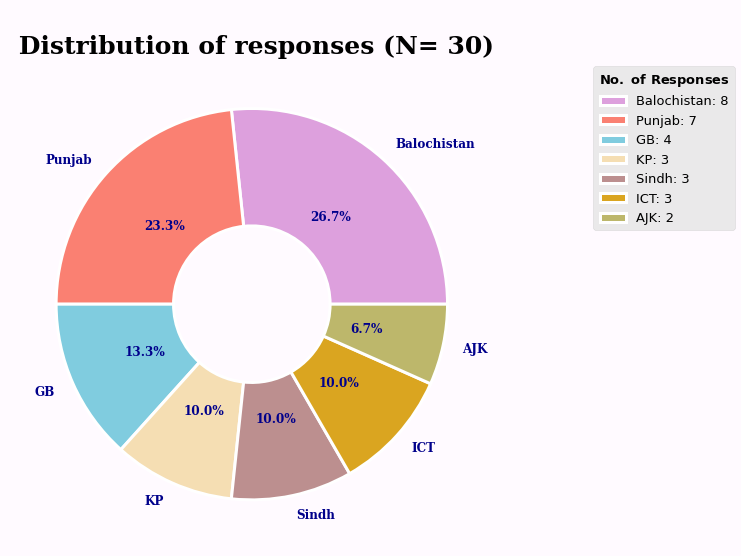

In [12]:
fig,ax= plt.subplots(figsize=(16,9))

# Define colors for Provinces
col_pie={
    'Balochistan':'plum',
    'Punjab':'salmon',
    'GB':(0.5, 0.8, 0.875),
    'KP':'wheat',
    'Sindh':'rosybrown',
    'ICT':'goldenrod',
    'AJK':'darkkhaki'}

# Plot Pie Chart
data_pie = df["Province"].value_counts().to_frame()
data_pie["Labels"] = data_pie.index+": "+data_pie["Province"].astype(str)
    
data_pie["Province"].plot(
        kind='pie',
        ax=ax,  
        autopct='%1.1f%%',
        colors= [col_pie[v] for v in data_pie.index],
        textprops={'fontsize': 12,'color':'darkblue','fontweight':550,'family':'serif'},
        wedgeprops = {'width':0.6,'linewidth':3, 'edgecolor':(1,1,1,1)})
    
ax.legend(
        loc='upper right', bbox_to_anchor=(1.5, 1),labels=data_pie["Labels"],prop={'size': 13}, 
        title="$\\bf{No.\ of\ Responses}$", title_fontsize=13)
ax.set_title(
        f"\n Distribution of responses (N= {data_pie['Province'].sum()})", 
        loc='center', fontsize=25, fontweight="bold",family='serif')
ax.set_ylabel("")
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))

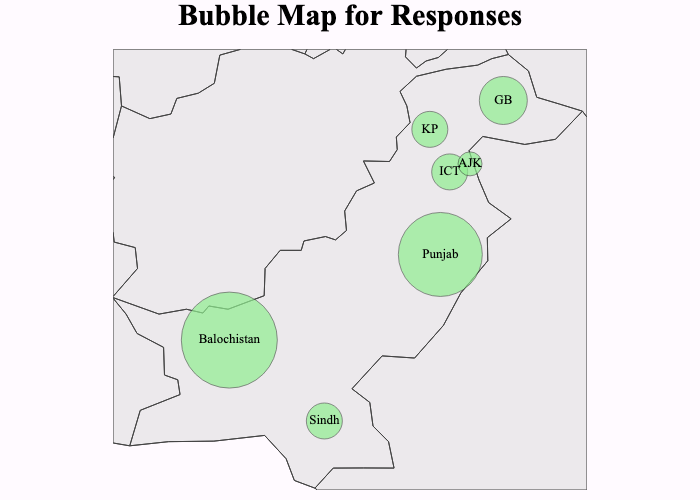

In [13]:
# Create a dataframe for lat_long data
lat_long= pd.DataFrame({
    'Province':["Punjab","Sindh","KP","Balochistan","GB","ICT","AJK"],
    'Lat':[31.1704,25.8943,34.9526,28.4907,35.8026,33.6844,33.9259],
    'Long':[72.7097,68.5247,72.3311,65.0958,74.9832,73.0479,73.7810]
    }).set_index("Province")

# Join Province Counts with Lat Long data
data_map = df["Province"].value_counts().to_frame()
data_map = data_map.join(lat_long)
data_map = data_map.reset_index()
data_map.rename(columns={'index':'Region'}, inplace=True)

# Plot Bubble map
fig = go.Figure()
fig.add_trace(go.Scattergeo(
                    lat=data_map["Lat"],lon=data_map["Long"],
                    marker = dict(
                    size = data_map["Province"]*12,
                    color='lightgreen',
                    line_color='rgb(40,40,40)',
                    line_width=0.7),
                    showlegend=False)
            )

fig.add_trace(go.Scattergeo(
                    lat=data_map["Lat"],lon=data_map["Long"],
                    text=data_map["Region"],
                    textposition="middle center",
                    textfont=dict(size =13, color='black', family='serif'),
                    mode='text',
                    showlegend=False)
                )

fig.update_layout(
        title_text='<b>Bubble Map for Responses',
        titlefont=dict(size =30, color='black', family='serif'),
        title_x=0.5,
        geo=dict(scope='asia',lataxis_range=[23.9,37.5], lonaxis_range=[60.9, 78],
        landcolor = 'rgba(217, 217, 217,0.5)',
        showcountries = True,
        showcoastlines=True,
        bgcolor='rgb(255,250,255)'),
        paper_bgcolor='rgb(255,250,255)',
        margin={"r":10,"t":50,"l":10,"b":10}
    )
fig.show("png")


In [14]:
# Define function for plotting barchars
def plot_bars(col,barcolors):
    """
    This function plots a barchart for a given column
    input: Relevant column and colors for barcharts
    output: piechart

    """
    data_bar= pd.crosstab(df[col],df["Province"],dropna=False)
    data_bar["Total"] = data_bar.sum(axis=1)

    #Convert numbers to percentages
    data_bar= data_bar.apply(lambda r: r*100/r.sum(),axis=0)
    data_bar= data_bar.round(decimals=1)

    #Reorder columns
    data_bar= data_bar.loc[:,["Punjab","Sindh","KP","Balochistan","GB","ICT","AJK","Total"]]
    
    #Plot barchart
    fig,ax= plt.subplots(figsize=(48,20))
    data_bar.T.plot.bar(
        ax=ax, rot=0, legend=False, 
        width=0.8,color=barcolors, edgecolor='k')

    # Add this loop to add the annotations
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height>0:
            x, y = p.get_xy() 
            ax.annotate(
                height, (x + width/2, height+1.02),ha='center',
                fontsize=25,fontweight="bold", color='darkblue')

    ax.legend(loc='best',prop={'size': 30})
    ax.set_title("\n"+data_bar.index.name+"\n", loc='center', fontsize=50, fontweight="bold", family='serif')
    ax.set_xlabel('Region',fontsize=40, fontweight="bold",family='serif')
    ax.set_ylabel('Percentage',fontsize=40, fontweight="bold",family='serif')
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    
    fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))
    fig.tight_layout()

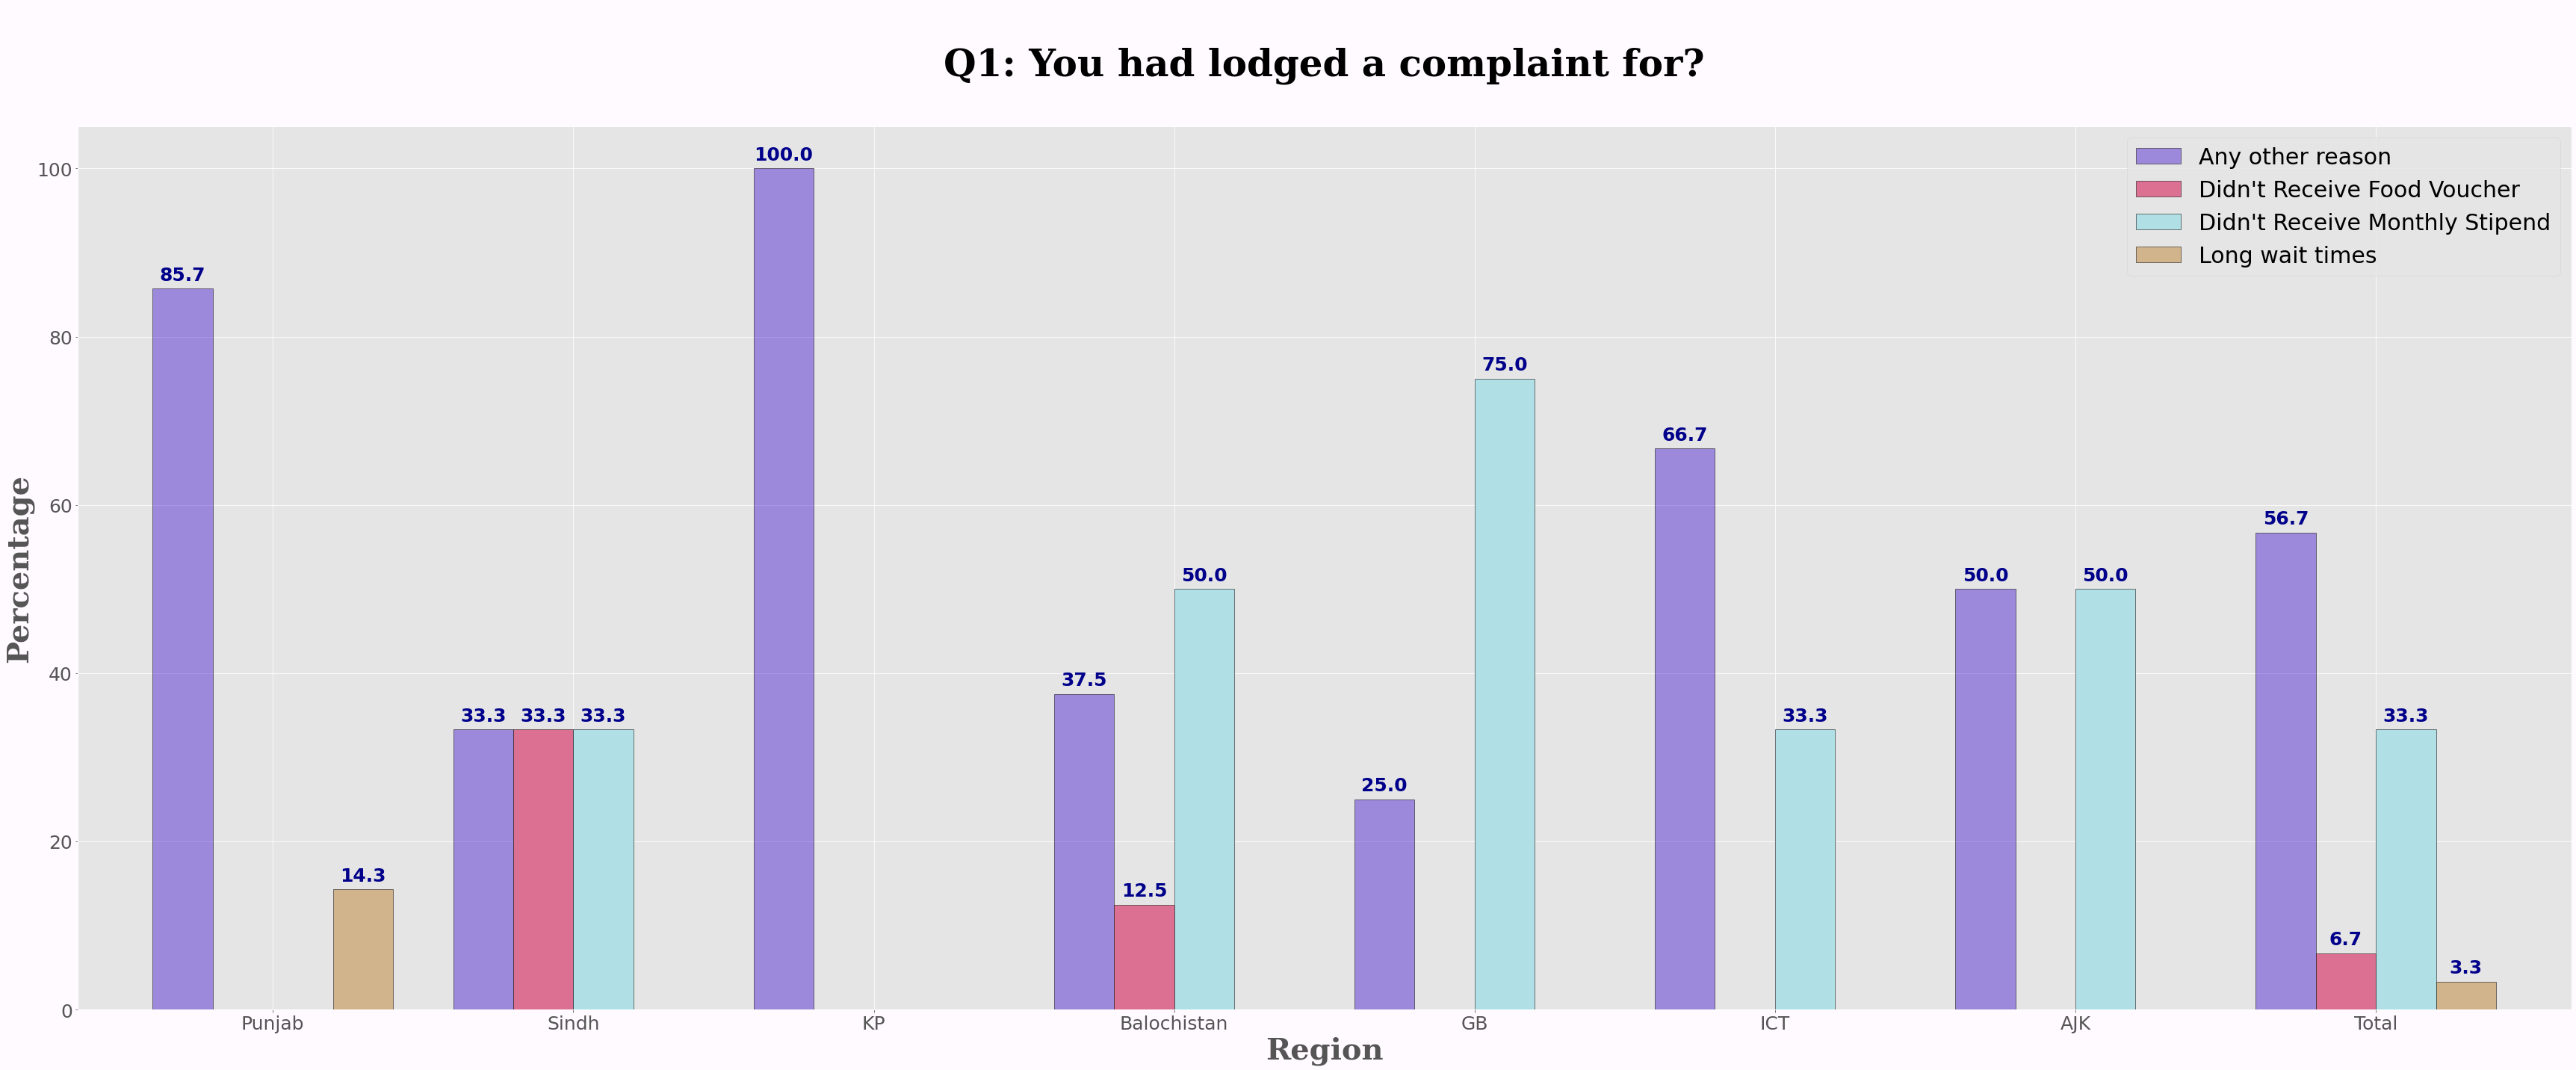

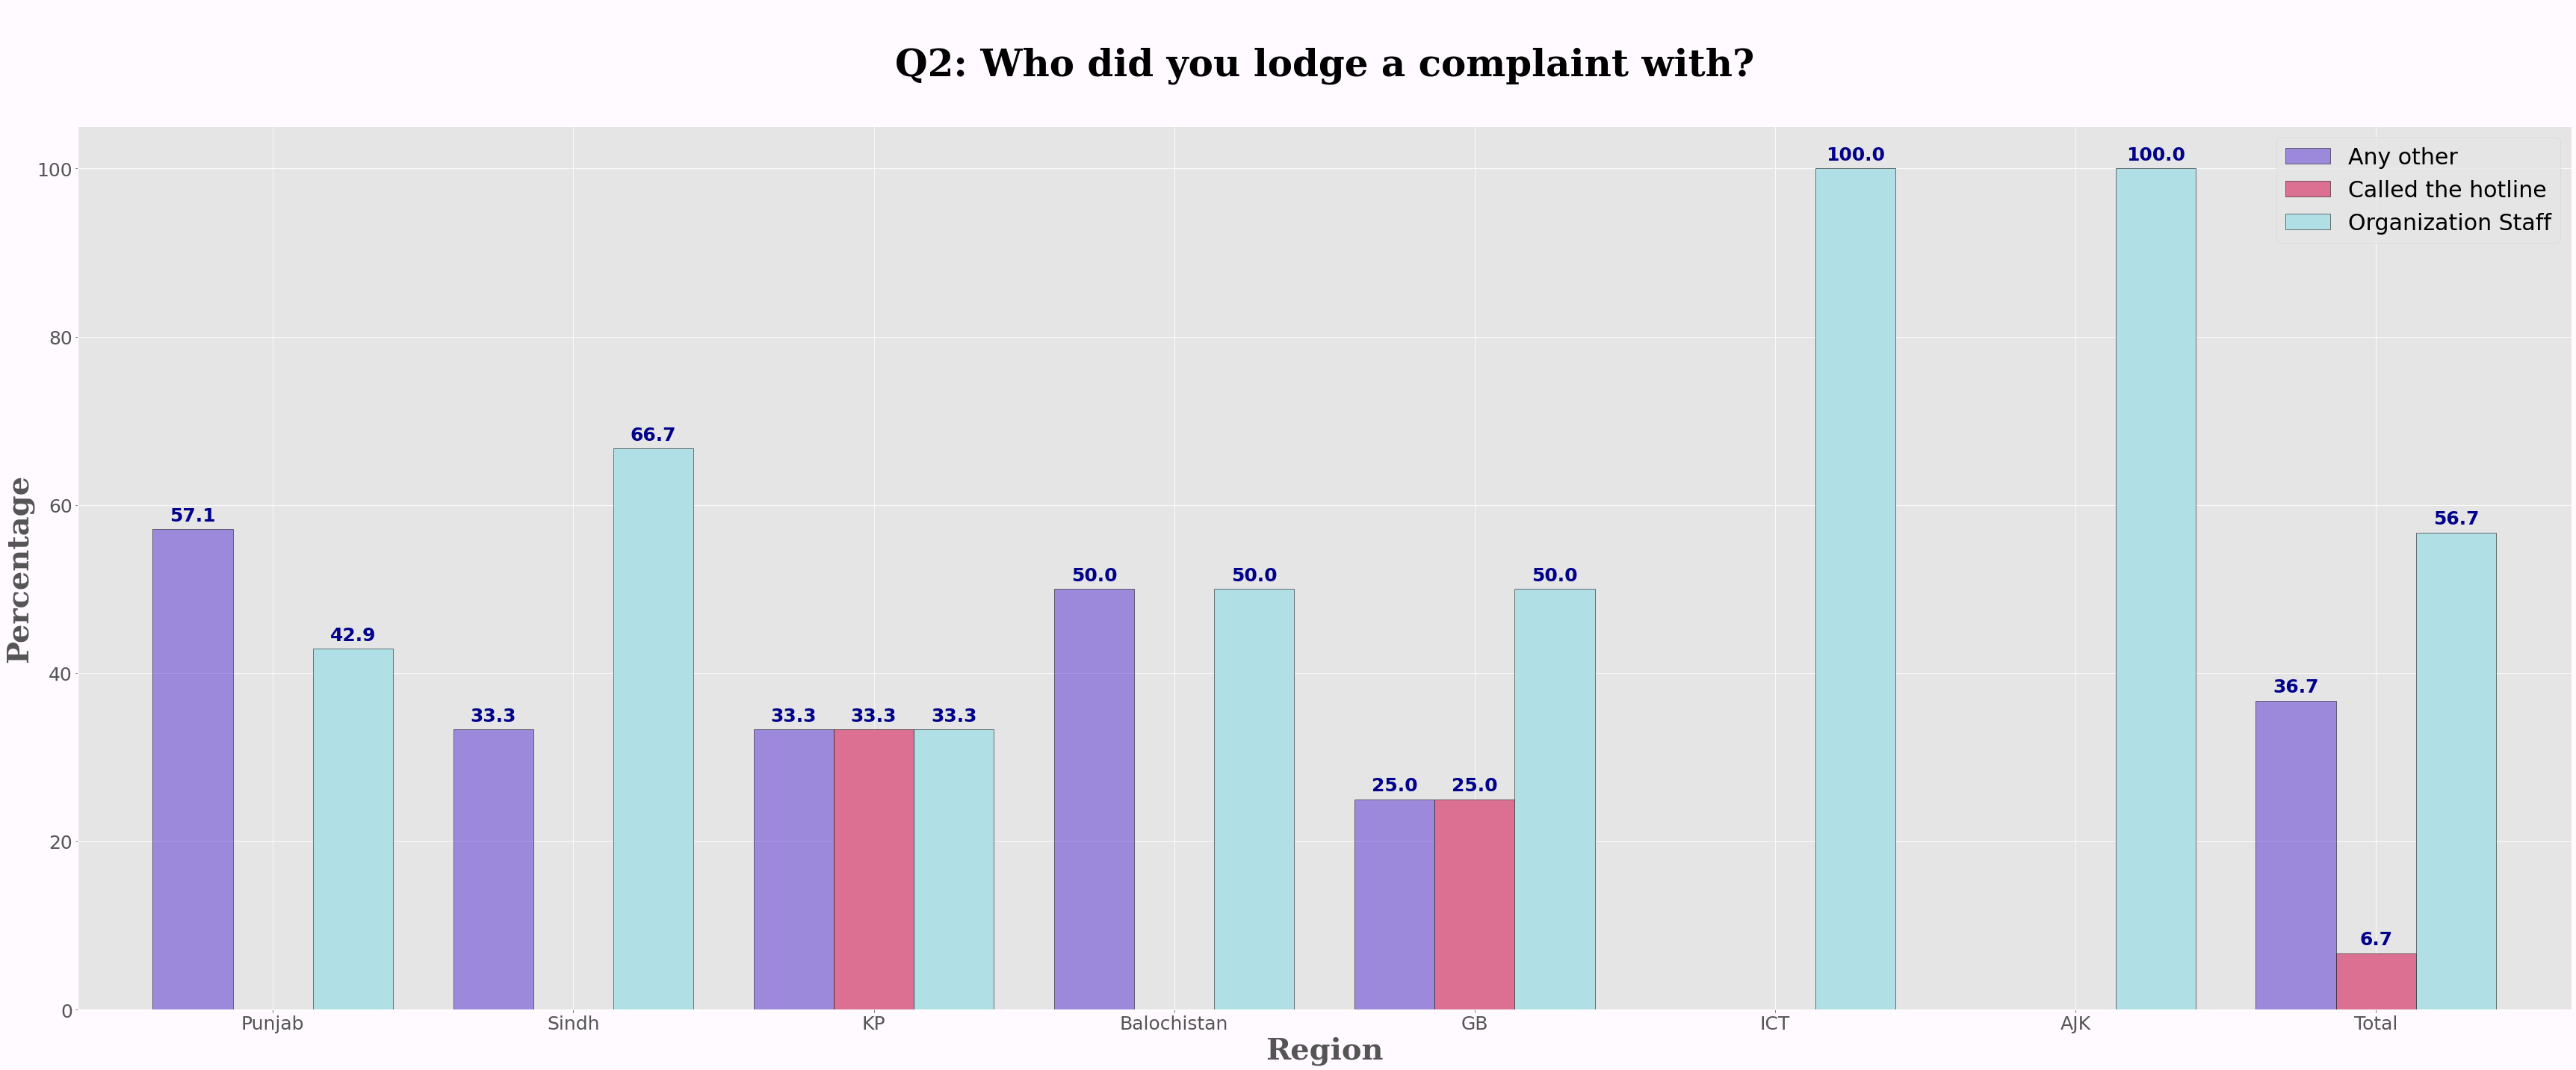

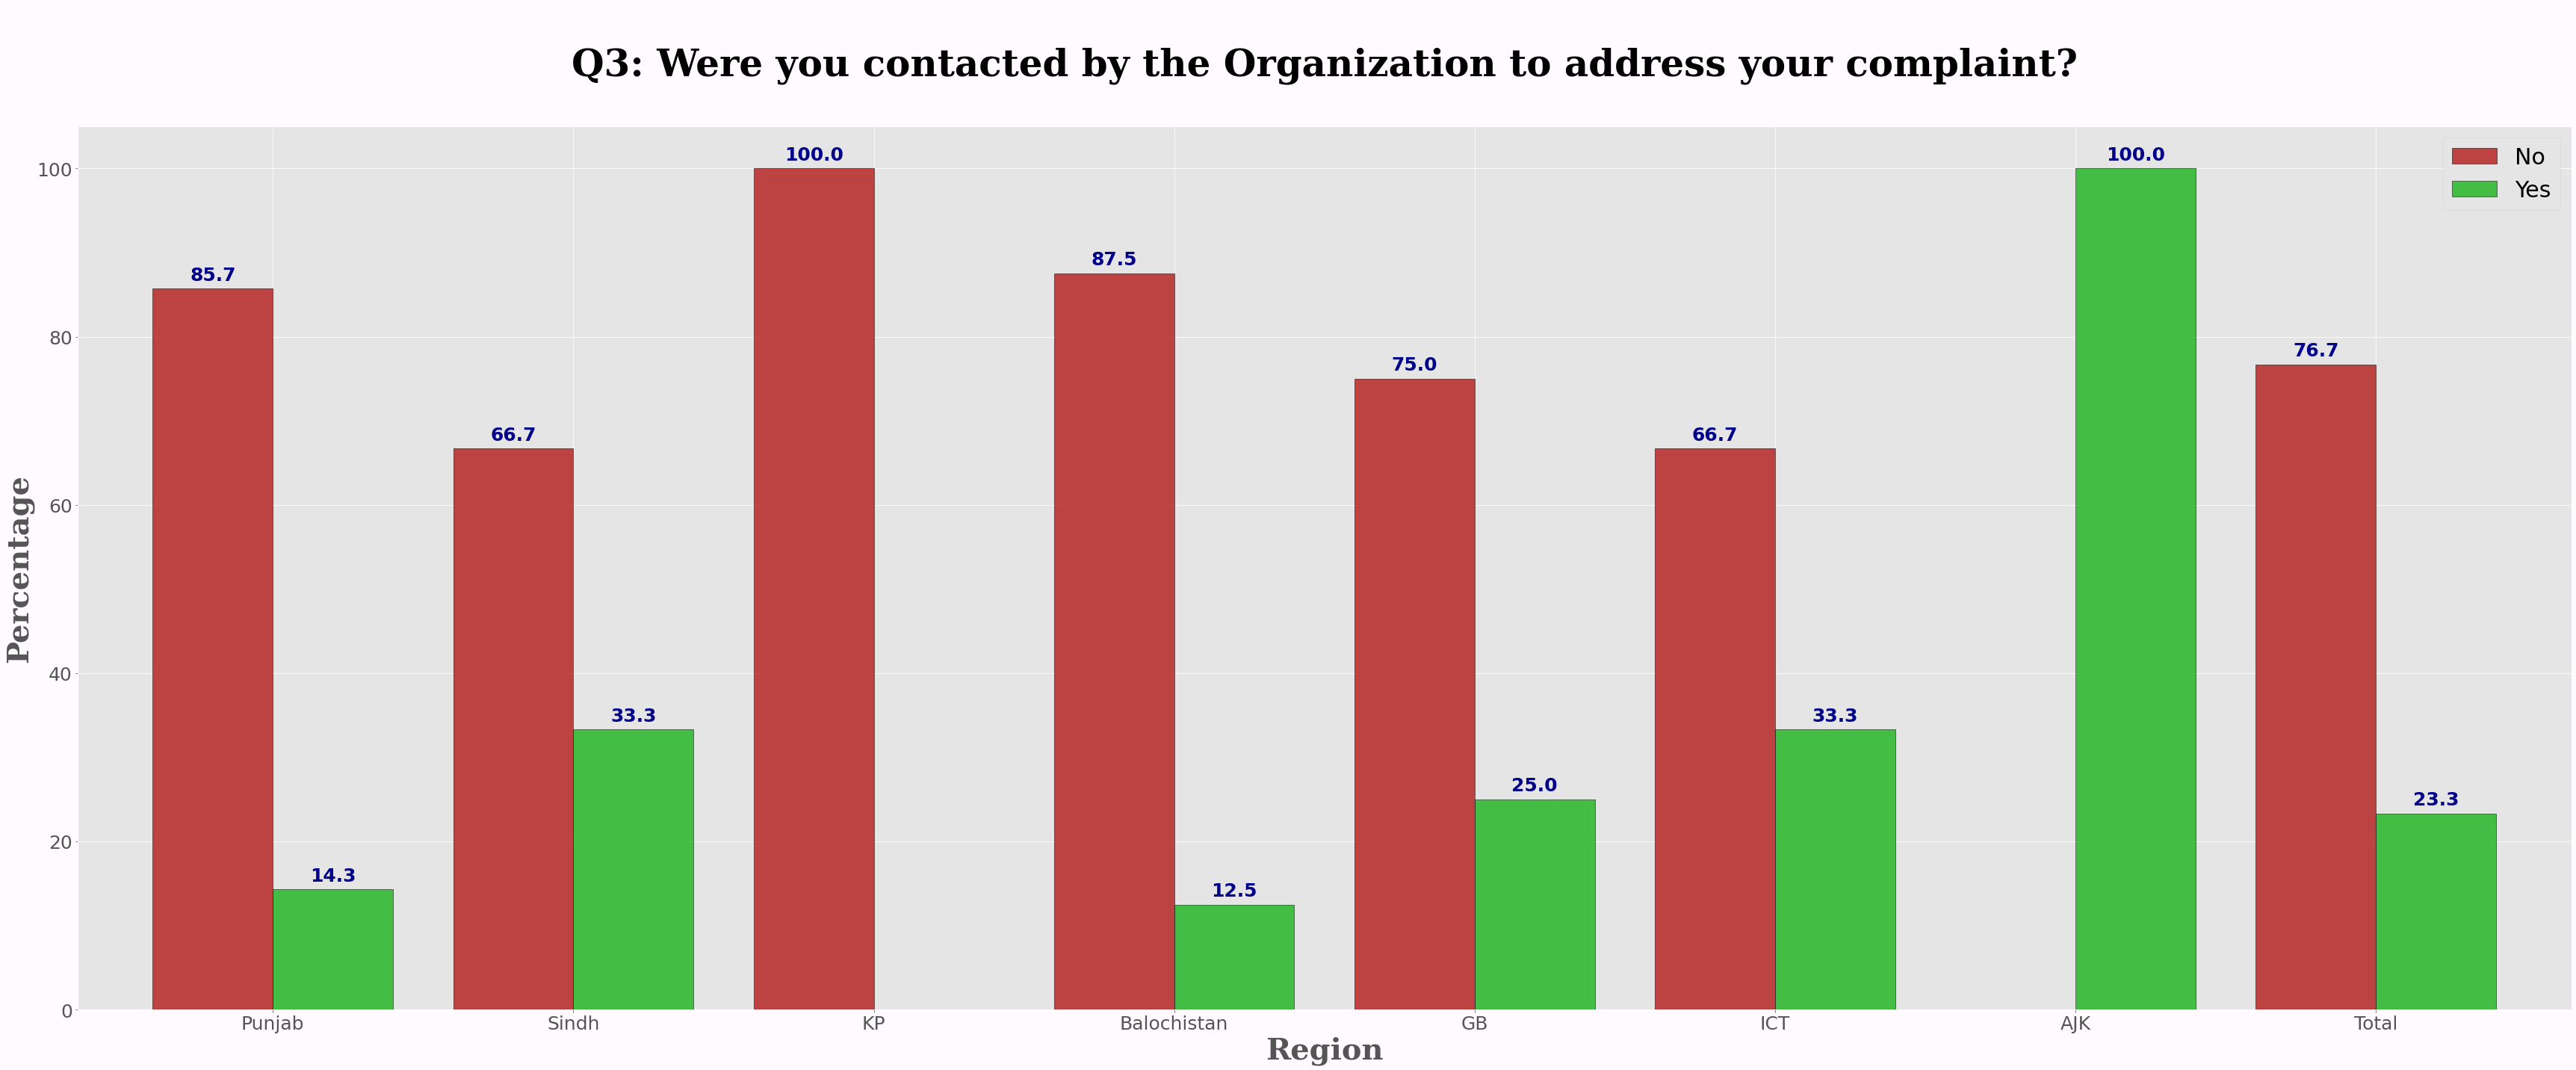

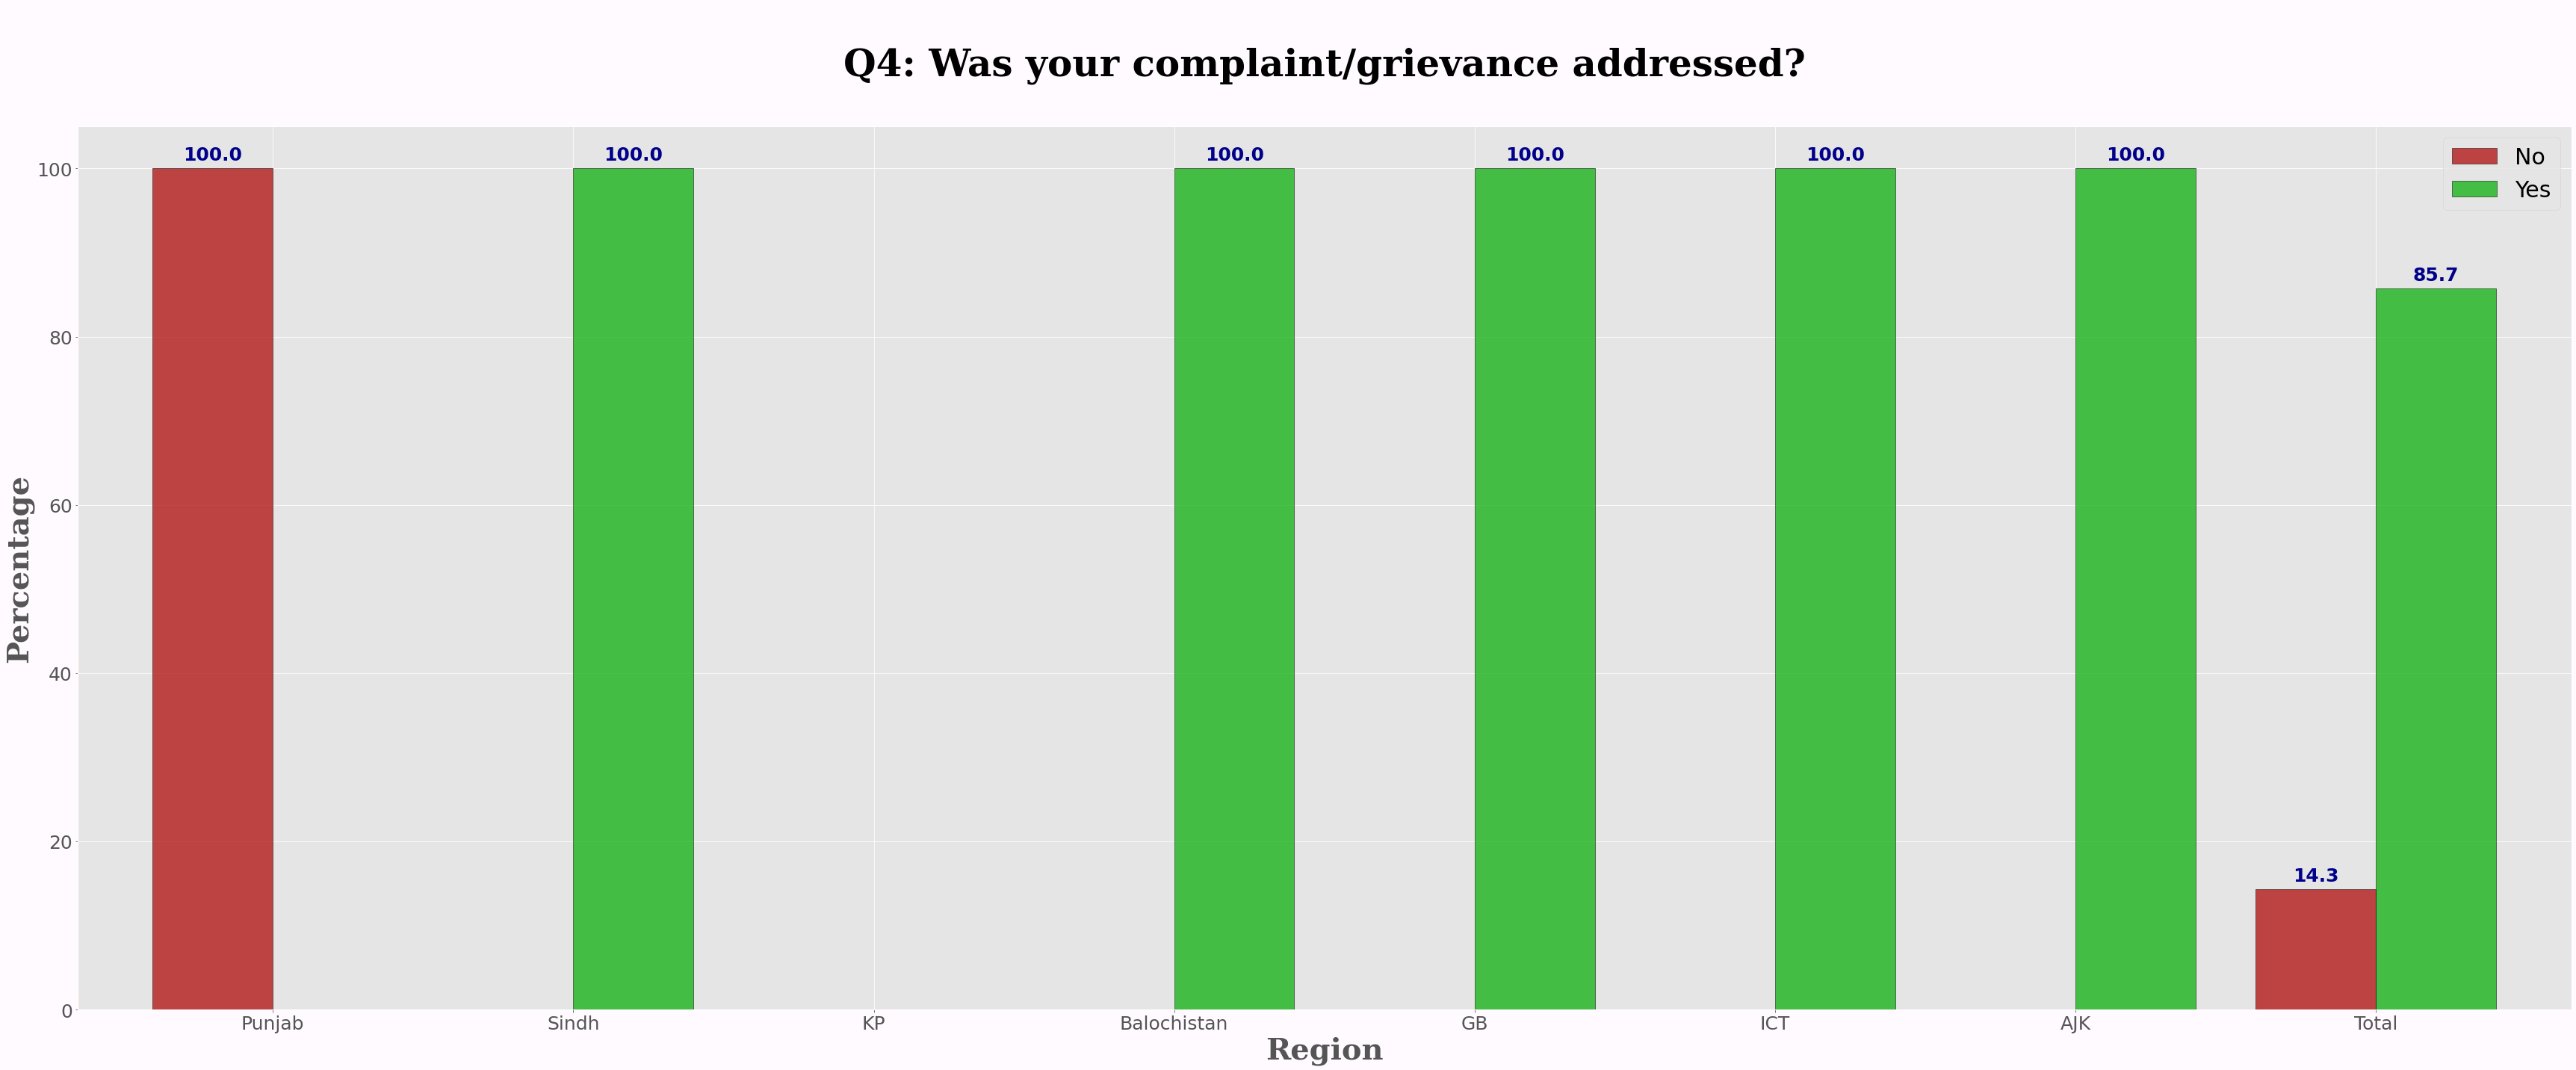

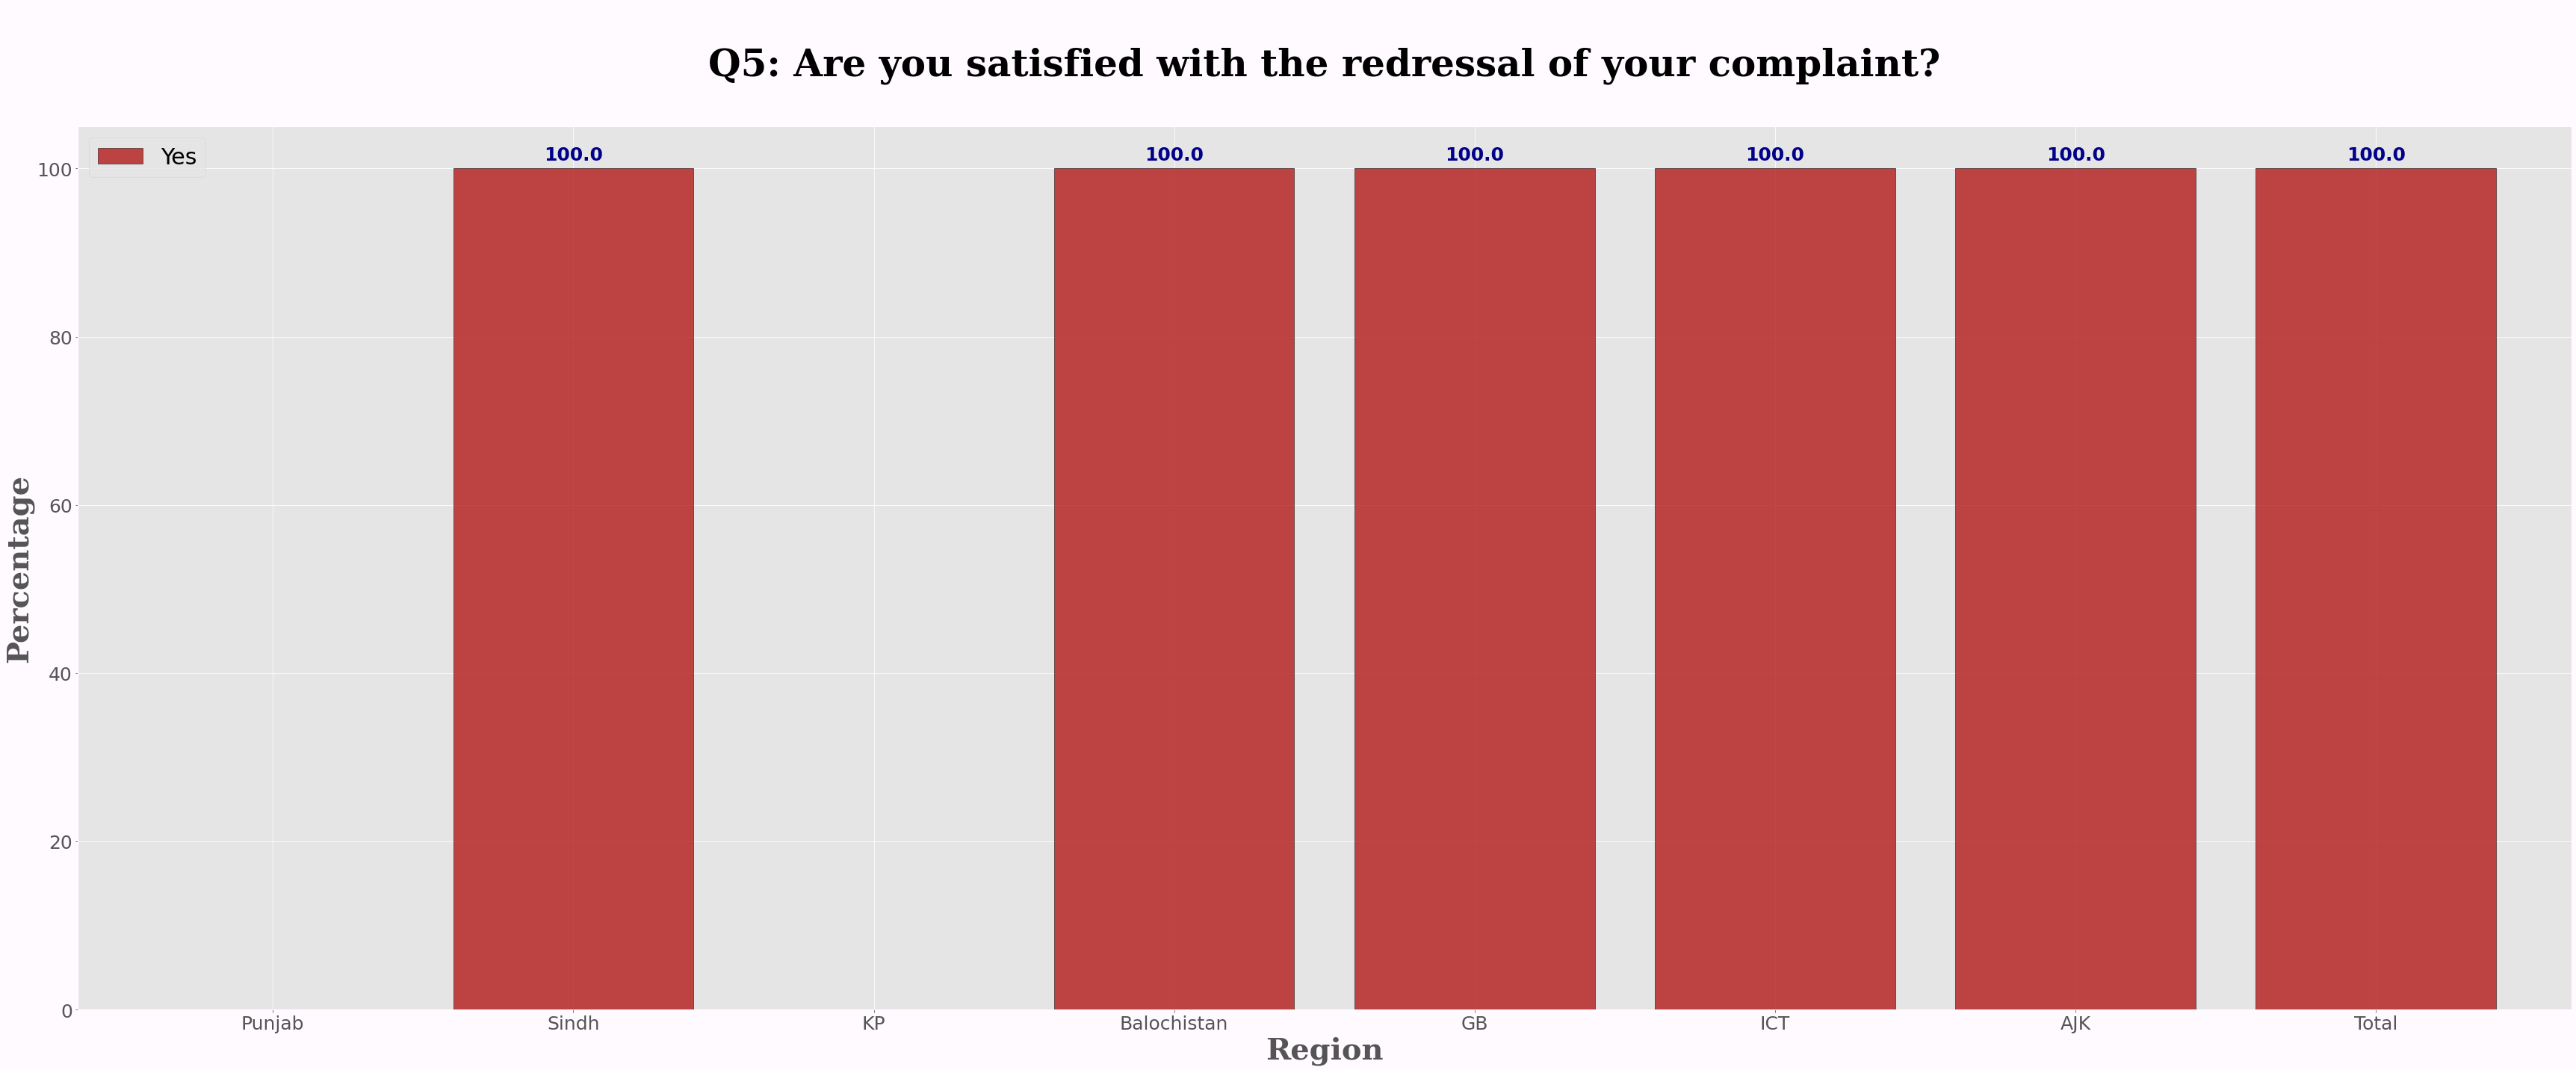

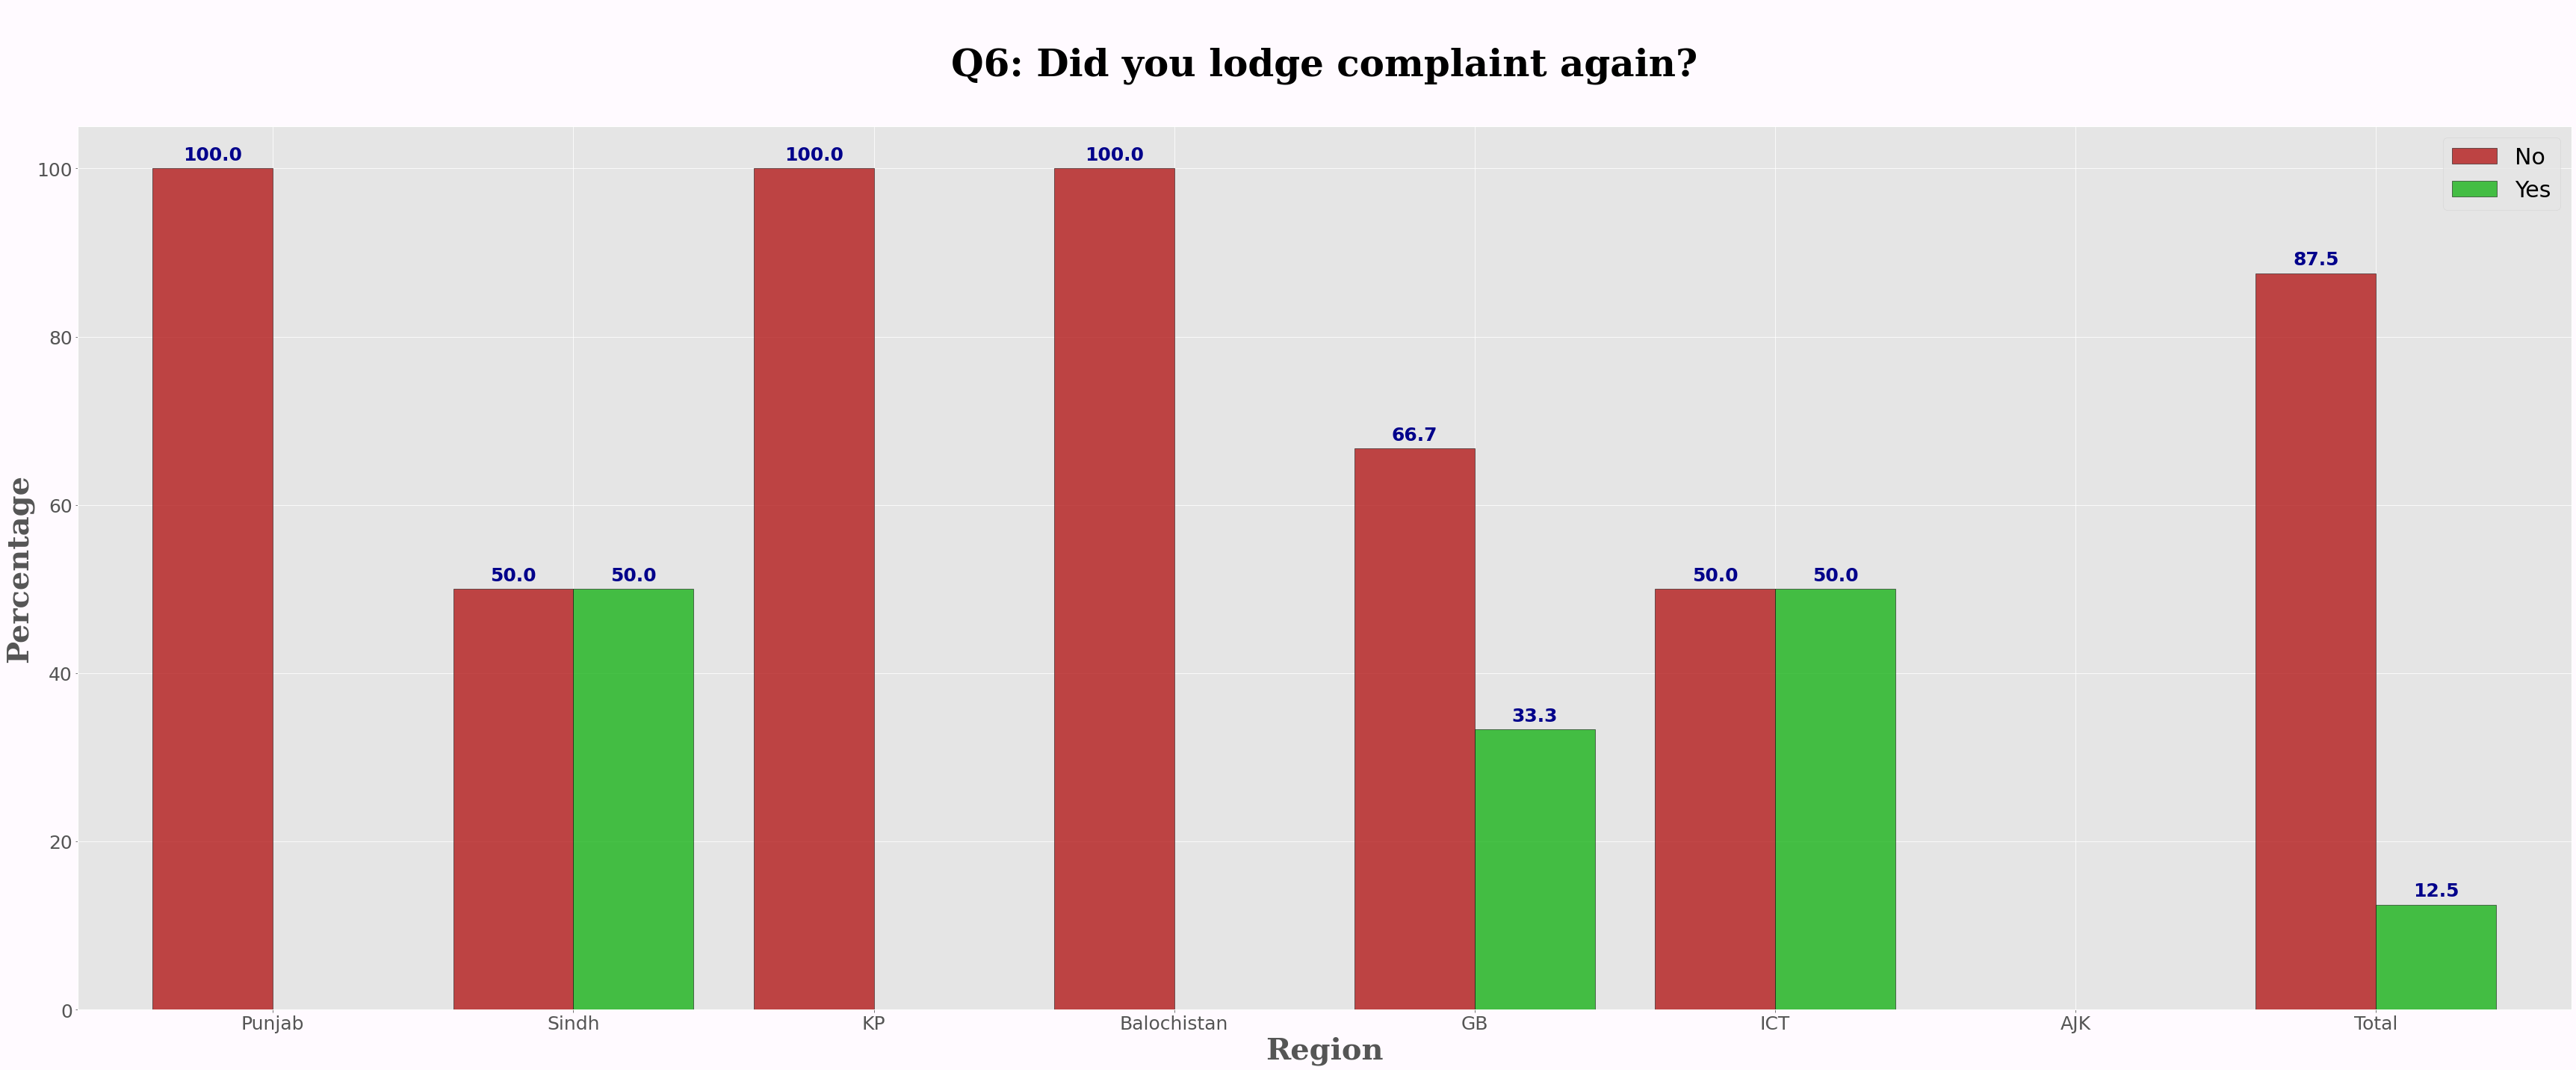

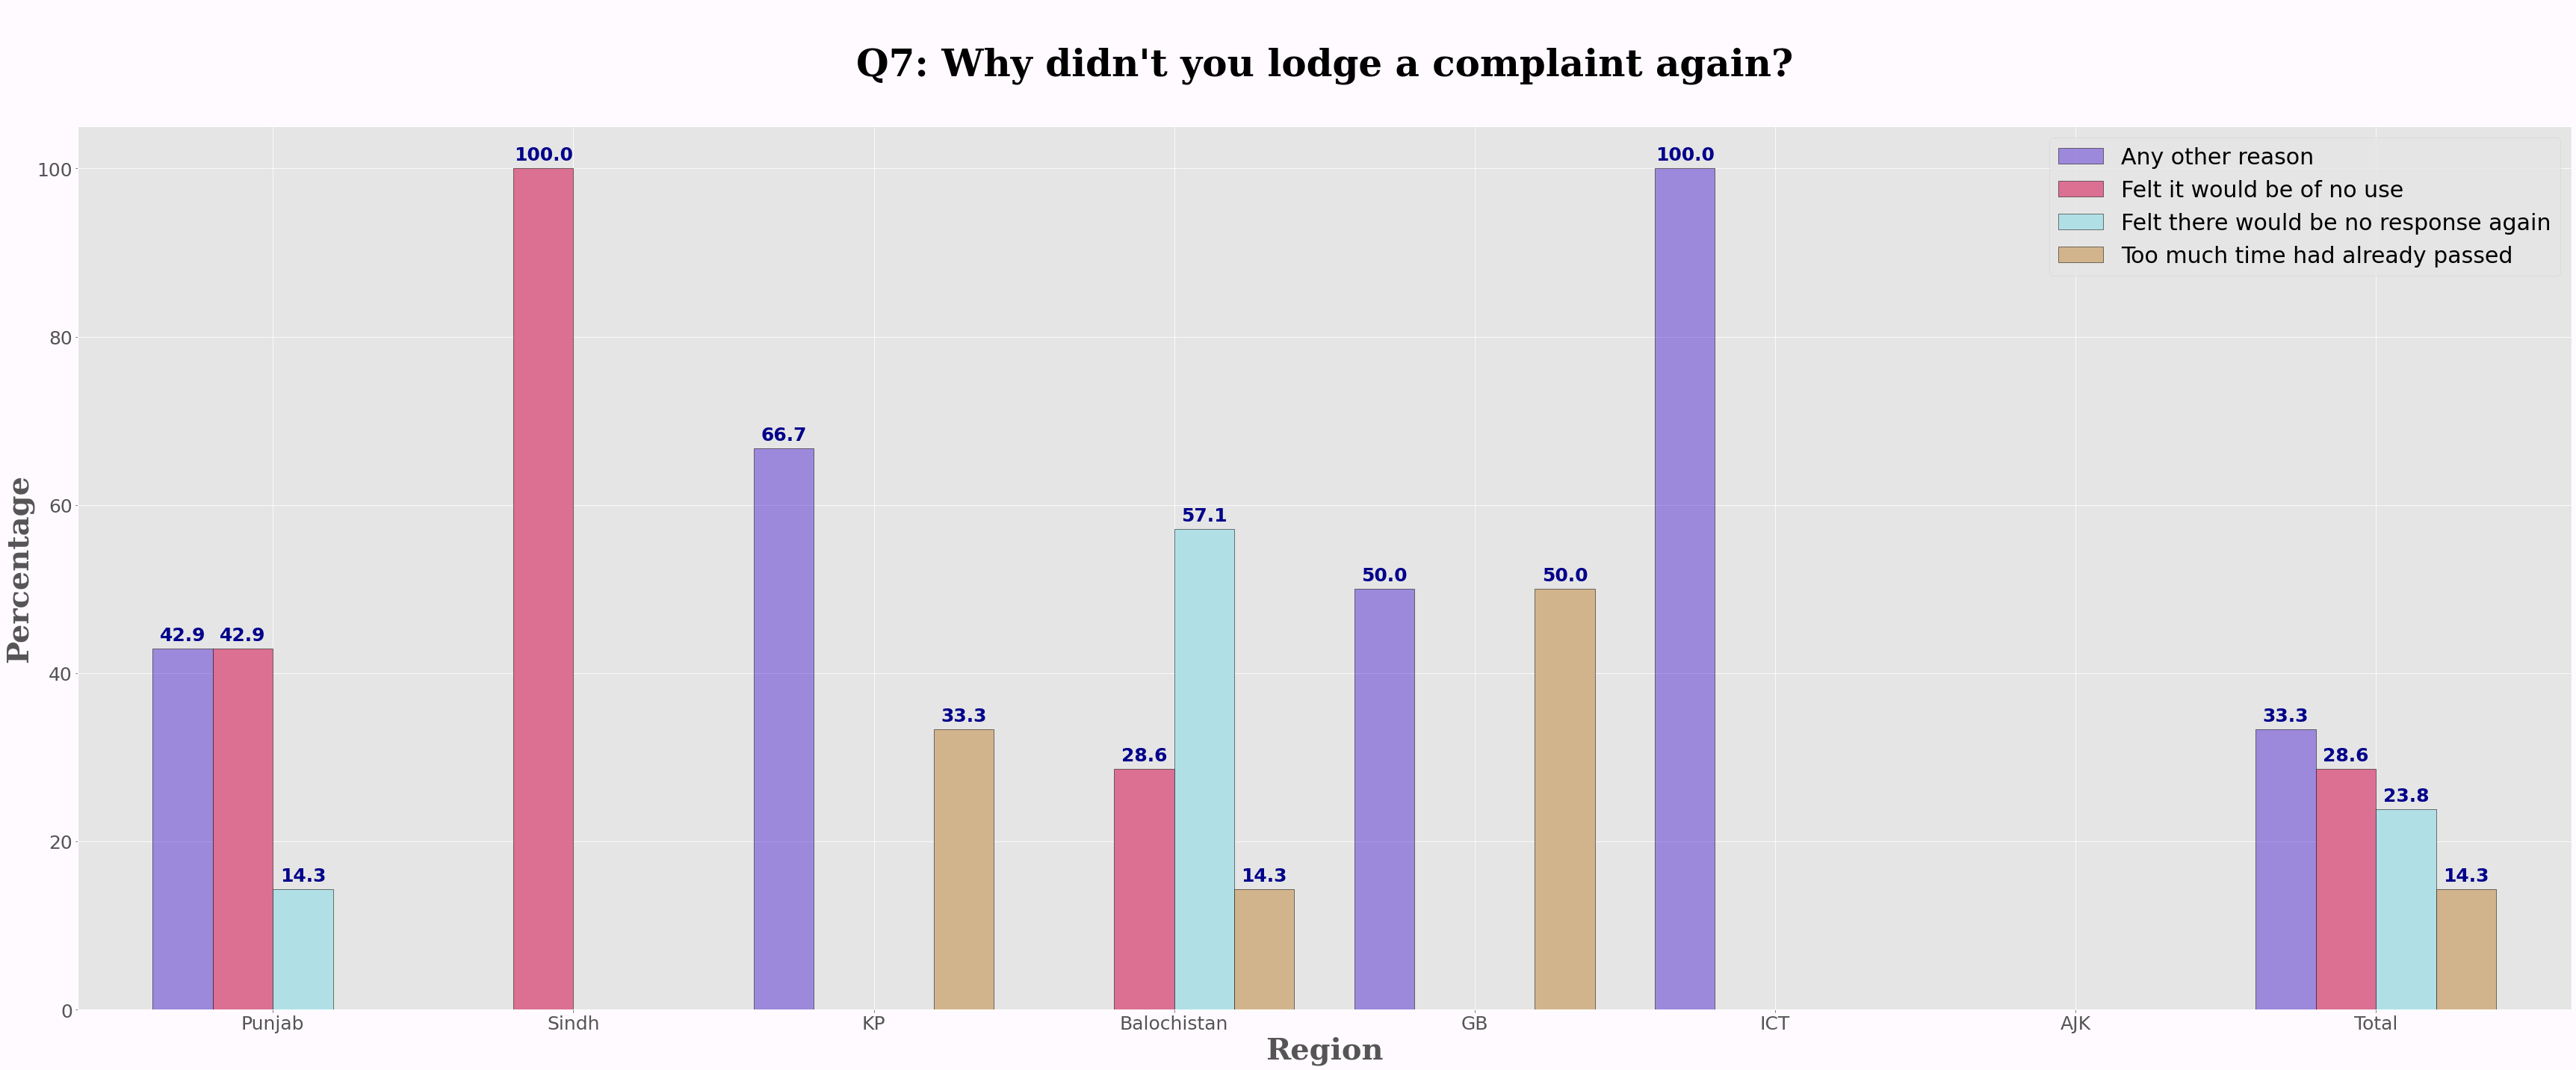

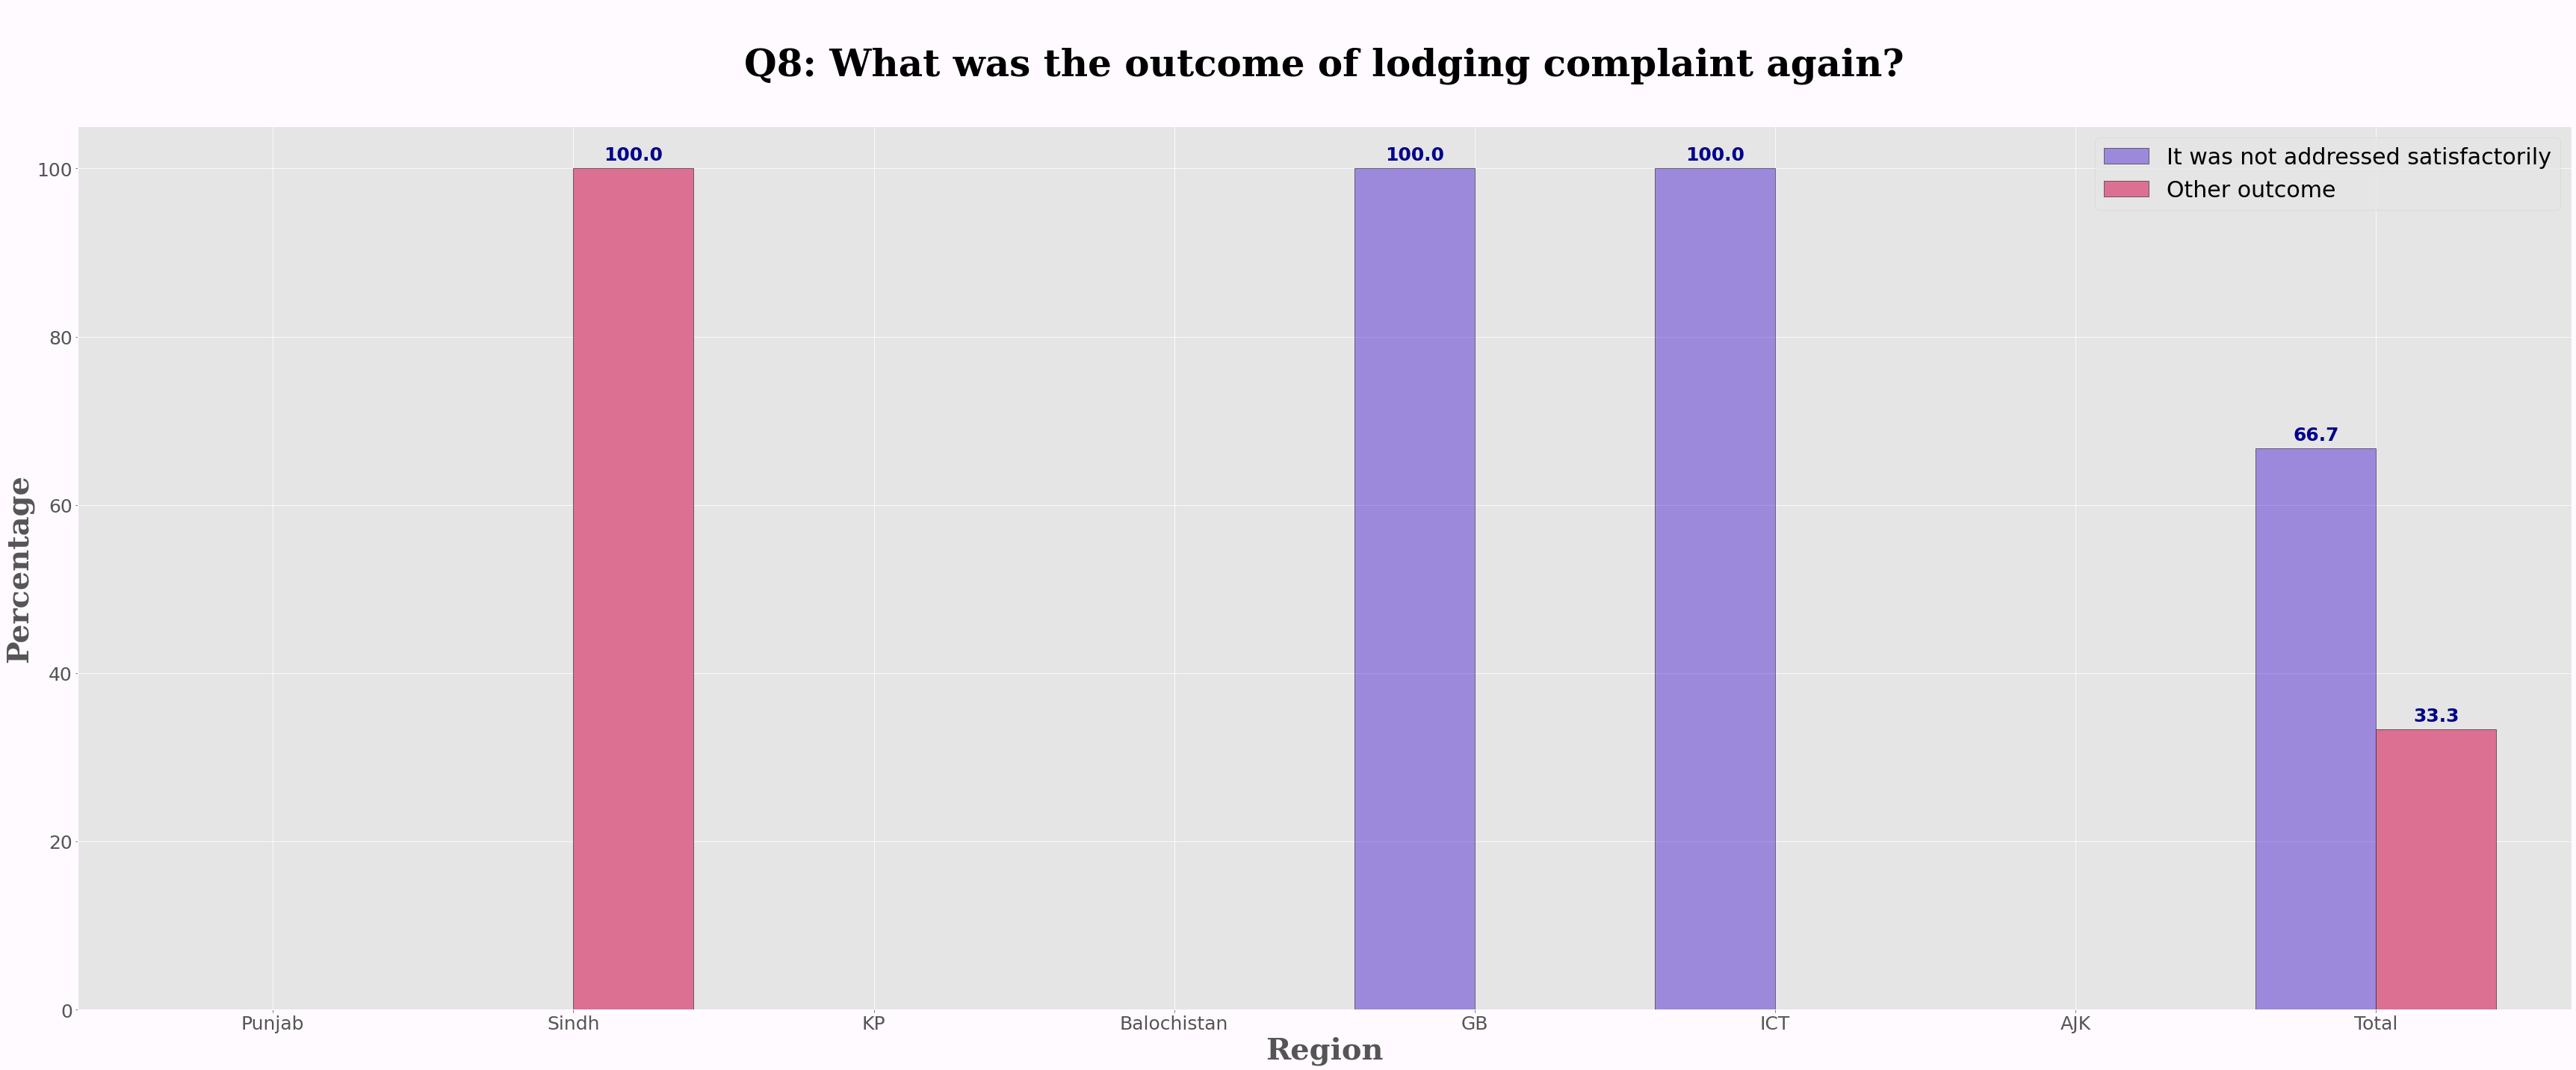

In [15]:
# Define colors for Barcharts

# Green and Red colors for Yes/No Questions
col_yn=[(0.7,0.1,0.1,0.8),(0.1,0.7,0.1,0.8)]

# Colors for other questions
clr=[(0.2,0,0.8,0.4),'palevioletred','powderblue','tan']

# Plot Bar charts
for i in range(1,9):
    if i in range(3,7):
        # Yes and No Questions
        plot_bars(df.columns[i],col_yn)
    else:
        # All other questions
        plot_bars(df.columns[i],clr)


In [16]:
! jupyter nbconvert --to webpdf --no-input Grievance_redressal_sampledata.ipynb

[NbConvertApp] Converting notebook Grievance_redressal_sampledata.ipynb to webpdf
[NbConvertApp] Writing 1196965 bytes to Grievance_redressal_sampledata.pdf
